# 5주차 — 튜닝 + Ablation (A0 baseline + grid 5×5 + A1'/A2'/A3' + 선택 CQR)

> 계획서 v5.1 §9 W5 + `docs/ablation_plan_w3.md` 갱신본 직격.

## 본 노트북의 목표

| 작업 | 계획서 근거 | 산출물 |
|------|------------|--------|
| §1. **C3 — A0 multi-seed 검증** (W4 검증 deferred 작업) | LOG #36/#37 | `reports/lstm_a0_multiseed_w5.csv` |
| §2. **수동 grid 5×5** (lr × hidden) | §5.5 | `reports/grid_5x5_w5.csv` + `w5_01_grid_heatmap.png` |
| §3. A0 final baseline (best HP) | §9 | `models/lstm_a0_final_w5.pt`, `reports/lstm_a0_final_eval_w5.csv` |
| §4. **A1' 환율 ablation (필수)** | §3.2(b) | `reports/ablation_a1_w5.csv` |
| §5. A2' kospi (시간 여유 시) | §3.2(b) | 동일 |
| §6. A3' kr_ppi (시간 여유 시) | §3.2(b) | 동일 |
| §7. (선택) CQR 후처리 | §5.6 | `reports/cqr_post_w5.csv` |
| §8. 통합 비교표 (Naive/ARIMA/XGBoost/W4 raw/A0/A1') | §9 | `reports/baseline_results_w5.csv` |

## 입력 (W4 검증 산출물)

- `data/processed/features_v1_candidate.csv` — 9 freeze 변수 + 타겟
- `data/processed/features_with_lags_v1.csv` — Lag/Rolling + Δy 라벨
- `data/interim/wide_daily_filled.csv` — krw_usd/kospi/kr_ppi 추출용 (A1'/A2'/A3')
- `models/scaler_robust_train.pkl` — split 정의 (train/cal/val/test)
- `reports/lstm_diff_ablation_w4.csv` — A0 사전 결과 (single-seed 42)
- `reports/baseline_results_w4.csv` — Naive/ARIMA/XGBoost/W4 raw

## 입력 변환 (모든 ablation 공통)

**Δfeature[t-1] 강제** (계획서 §2.2 1-step ahead causal forecast):
- `df_diff = X[FROZEN].diff().shift(1)` → `df_diff[t] = X[t-1] - X[t-2]`
- A1'/A2'/A3' 추가 변수도 동일 변환: `Δkrw_usd[t-1]`, `Δkospi[t-1]`, `Δkr_ppi[t-1]`
- A3' (kr_ppi) 는 월별 변수 → `wide_daily_filled.csv` 의 ffill 값에 추가 발표일 시프트 검증 (CL-01)

---

## 0. 환경 + 데이터 로드

In [1]:
import importlib.util, subprocess, sys
for _name in ['torch', 'sklearn', 'matplotlib', 'yaml', 'statsmodels']:
    if importlib.util.find_spec(_name) is None:
        pip_name = {'sklearn':'scikit-learn','yaml':'pyyaml'}.get(_name, _name)
        subprocess.check_call([sys.executable,'-m','pip','install','-q',pip_name])

import pickle, json, time
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data'
MODELS_DIR   = PROJECT_ROOT / 'models'
REPORT_DIR   = PROJECT_ROOT / 'reports'
FIG_DIR      = REPORT_DIR / 'figures'
DOCS_DIR     = PROJECT_ROOT / 'docs'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'configs' / 'config.yaml', encoding='utf-8') as f:
    CONFIG = yaml.safe_load(f)
LSTM_CFG = CONFIG['models']['lstm']
LOOKBACK = CONFIG['features']['lookback_window']
QUANTILES = [0.05, 0.5, 0.95]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'torch {torch.__version__} · device: {DEVICE}')
print(f'lookback={LOOKBACK}, quantiles={QUANTILES}')

PROJECT_ROOT: C:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast
torch 2.11.0+cpu · device: cpu
lookback=30, quantiles=[0.05, 0.5, 0.95]


In [2]:
# 데이터 로드
fv = pd.read_csv(DATA_DIR/'processed/features_v1_candidate.csv',
                 index_col='date', parse_dates=['date']).sort_index()
fwl = pd.read_csv(DATA_DIR/'processed/features_with_lags_v1.csv',
                  index_col='date', parse_dates=['date']).sort_index()
raw_wide = pd.read_csv(DATA_DIR/'interim/wide_daily_filled.csv',
                       index_col=0, parse_dates=[0]).sort_index()
with open(MODELS_DIR/'scaler_robust_train.pkl','rb') as f:
    SPLIT = pickle.load(f)['split']

FROZEN = ['kr_treasury_3y','kr_base_rate','us_treasury_10y','us_fed_funds',
          'us_breakeven_10y','vix','sp500','dxy']

print(f'features_v1: {fv.shape}, features_with_lags: {fwl.shape}, raw_wide: {raw_wide.shape}')
print(f'\nSPLIT 구간:')
for k,v in SPLIT.items():
    print(f'  {k:6s}: {v[0]} ~ {v[1]}')
print(f'\nFROZEN ({len(FROZEN)}): {FROZEN}')

features_v1: (3757, 10), features_with_lags: (3726, 109), raw_wide: (4174, 24)

SPLIT 구간:
  train : 2010-01-01 ~ 2020-12-31
  cal   : 2021-01-01 ~ 2021-12-31
  val   : 2022-01-01 ~ 2022-12-31
  test  : 2023-01-01 ~ 2025-12-31

FROZEN (8): ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'sp500', 'dxy']


---

## 0b. 공통 유틸 — Δfeature 변환 + 시퀀스 + LSTM + 학습/평가

In [3]:
def slice_period(df, p):
    s, e = SPLIT[p]; return df.loc[s:e]

def build_diff_features(feature_df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """X[t] = X_raw[t-1] - X_raw[t-2] (1-step ahead causal lag-1)"""
    df = feature_df[cols].diff().shift(1)
    df.columns = [f'd_{c}' for c in cols]
    return df

def fit_scaler_and_transform(df_diff: pd.DataFrame):
    """Train-only fit (CL-02) → val/cal/test transform."""
    X_train_raw = slice_period(df_diff, 'train').dropna()
    X_cal_raw   = slice_period(df_diff, 'cal'  ).dropna()
    X_val_raw   = slice_period(df_diff, 'val'  ).dropna()
    X_test_raw  = slice_period(df_diff, 'test' ).dropna()
    sc = RobustScaler().fit(X_train_raw)
    def tr(d): return pd.DataFrame(sc.transform(d), index=d.index, columns=d.columns)
    return sc, tr(X_train_raw), tr(X_cal_raw), tr(X_val_raw), tr(X_test_raw)

def make_sequences(X_df, y_ser, lookback):
    idx = X_df.index.intersection(y_ser.index)
    X = X_df.loc[idx].to_numpy(dtype=np.float32)
    y = y_ser.loc[idx].to_numpy(dtype=np.float32)
    seqs, tgts, dates = [], [], []
    arr = idx.to_numpy()
    for t in range(lookback - 1, len(X)):
        if np.isnan(y[t]) or np.isnan(X[t-lookback+1:t+1]).any(): continue
        seqs.append(X[t-lookback+1:t+1]); tgts.append(y[t]); dates.append(arr[t])
    return np.stack(seqs), np.array(tgts, dtype=np.float32), np.array(dates)

class QuantileLSTM(nn.Module):
    def __init__(self, input_dim, hidden, layers, dropout, n_q):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True,
                            dropout=dropout if layers>1 else 0.0)
        self.head = nn.Linear(hidden, n_q)
    def forward(self, x):
        out, _ = self.lstm(x); return self.head(out[:,-1,:])

def pinball_loss(pred, target, q=QUANTILES):
    target = target.unsqueeze(1)
    q_t = torch.tensor(q, dtype=pred.dtype, device=pred.device).unsqueeze(0)
    return torch.maximum(q_t*(target-pred), (q_t-1)*(target-pred)).mean()

class SeqDS(Dataset):
    def __init__(self, X, y): self.X=torch.from_numpy(X).float(); self.y=torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def train_one(Xs_train, ys_train, Xs_val, ys_val,
              hidden=64, layers=2, dropout=0.3, lr=1e-3,
              batch_size=32, max_epochs=100, patience=10, seed=42, verbose=False):
    torch.manual_seed(seed); np.random.seed(seed)
    g = torch.Generator(); g.manual_seed(seed)
    model = QuantileLSTM(Xs_train.shape[2], hidden, layers, dropout, len(QUANTILES)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    tr = DataLoader(SeqDS(Xs_train, ys_train), batch_size=batch_size, shuffle=True, generator=g)
    vl = DataLoader(SeqDS(Xs_val,   ys_val),   batch_size=batch_size, shuffle=False)
    best, wait, best_state = float('inf'), 0, None
    history = {'train':[], 'val':[]}
    for ep in range(1, max_epochs+1):
        model.train(); tl=[]
        for xb,yb in tr:
            xb,yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); l=pinball_loss(model(xb), yb); l.backward(); opt.step()
            tl.append(float(l.item()))
        model.eval(); vl_l=[]
        with torch.no_grad():
            for xb,yb in vl:
                xb,yb = xb.to(DEVICE), yb.to(DEVICE)
                vl_l.append(float(pinball_loss(model(xb), yb).item()))
        tr_l, vl_loss = float(np.mean(tl)), float(np.mean(vl_l))
        history['train'].append(tr_l); history['val'].append(vl_loss)
        if vl_loss < best - 1e-6:
            best=vl_loss; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            wait=0
        else:
            wait+=1
            if wait>=patience: break
    if best_state: model.load_state_dict(best_state)
    return model, best, history, ep

@torch.no_grad()
def predict_sorted(model, Xs):
    model.eval()
    p = model(torch.from_numpy(Xs).float().to(DEVICE)).cpu().numpy()
    arr = np.sort(p, axis=1)
    return {q: arr[:,i] for i,q in enumerate(QUANTILES)}

def pinball_np(y, p, q): d=y-p; return float(np.mean(np.maximum(q*d,(q-1)*d)))
def dir_acc(y, p):
    m = (np.sign(p)!=0)&(np.sign(y)!=0)
    return float((np.sign(p[m])==np.sign(y[m])).mean()) if m.sum() else float('nan')

def evaluate(preds, y, label):
    out = {'split': label}
    for q in QUANTILES:
        out[f'pinball_q{int(q*100):02d}'] = pinball_np(y, preds[q], q)
    out['coverage_90'] = float(np.mean((y>=preds[0.05])&(y<=preds[0.95])))
    out['sharpness_bp'] = float(np.mean(preds[0.95]-preds[0.05]))
    err = y - preds[0.5]
    out['rmse_q50_bp'] = float(np.sqrt(np.mean(err**2)))
    out['mae_q50_bp']  = float(np.mean(np.abs(err)))
    out['dir_acc_q50'] = dir_acc(y, preds[0.5])
    return out

print('✅ 공통 유틸 정의 완료')

✅ 공통 유틸 정의 완료


In [4]:
# A0 baseline 입력 준비 — Δfeature[t-1] 8개
df_diff_a0 = build_diff_features(fv, FROZEN)
scaler_a0, X_train_a0, X_cal_a0, X_val_a0, X_test_a0 = fit_scaler_and_transform(df_diff_a0)
y_train = slice_period(fwl, 'train')['delta_y_bp']
y_cal   = slice_period(fwl, 'cal')['delta_y_bp']
y_val   = slice_period(fwl, 'val')['delta_y_bp']
y_test  = slice_period(fwl, 'test')['delta_y_bp']

Xs_train_a0, ys_train, _      = make_sequences(X_train_a0, y_train, LOOKBACK)
Xs_cal_a0,   ys_cal,   _       = make_sequences(X_cal_a0,   y_cal,   LOOKBACK)
Xs_val_a0,   ys_val,   dt_val  = make_sequences(X_val_a0,   y_val,   LOOKBACK)
Xs_test_a0,  ys_test,  dt_test = make_sequences(X_test_a0,  y_test,  LOOKBACK)
print(f'A0 시퀀스: train{Xs_train_a0.shape} cal{Xs_cal_a0.shape} val{Xs_val_a0.shape} test{Xs_test_a0.shape}')

A0 시퀀스: train(2524, 30, 8) cal(209, 30, 8) val(205, 30, 8) test(672, 30, 8)


---

## 1. C3 — A0 multi-seed 검증 (W4 검증 deferred)

**목표**: A0 의 RMSE -8.4% 회복이 **seed 변동에 robust 한가** 를 정량 확인.
- seeds: 42, 123, 2024 (3회 실행)
- 동일 입력/하이퍼파라미터, seed 만 변경
- 보고: mean ± std (test split)
- 기준: std/mean < 5% → robust 판정

In [5]:
SEEDS = [42, 123, 2024]
ms_rows = []
ms_models = {}
for sd in SEEDS:
    t0 = time.time()
    model_a0, best_val, hist, n_ep = train_one(
        Xs_train_a0, ys_train, Xs_val_a0, ys_val,
        hidden=LSTM_CFG['hidden_units'], layers=LSTM_CFG['num_layers'],
        dropout=LSTM_CFG['dropout'], lr=LSTM_CFG['learning_rate'],
        batch_size=LSTM_CFG['batch_size'], max_epochs=LSTM_CFG['epochs'],
        patience=LSTM_CFG['early_stopping_patience'], seed=sd)
    elapsed = time.time() - t0
    ms_models[sd] = model_a0
    for split_name, Xs, y in [('train', Xs_train_a0, ys_train),
                              ('val', Xs_val_a0, ys_val),
                              ('test', Xs_test_a0, ys_test)]:
        ev = evaluate(predict_sorted(model_a0, Xs), y, split_name)
        ev['seed'] = sd; ev['n_epochs'] = n_ep; ev['best_val_pinball'] = best_val
        ms_rows.append(ev)
    print(f'  seed={sd}: best_val_pinball={best_val:.4f}, epochs={n_ep}, elapsed={elapsed:.1f}s')

ms_df = pd.DataFrame(ms_rows)
ms_df.to_csv(REPORT_DIR/'lstm_a0_multiseed_w5.csv', index=False)

# test split 의 mean ± std
test_ms = ms_df[ms_df['split']=='test']
print('\n=== A0 multi-seed (test split) — mean ± std ===')
metrics = ['pinball_q50','coverage_90','sharpness_bp','rmse_q50_bp','dir_acc_q50']
summary_rows = []
for m in metrics:
    mean, std = test_ms[m].mean(), test_ms[m].std()
    cv = std/abs(mean)*100 if mean else float('nan')
    robust = '✅' if cv < 5 else '⚠️'
    summary_rows.append({'metric': m, 'mean': round(mean,3), 'std': round(std,3),
                         'CV(%)': round(cv,1), 'robust': robust})
    print(f'  {m:18s}  mean={mean:.4f}  std={std:.4f}  CV={cv:.1f}%  {robust}')
summary_df = pd.DataFrame(summary_rows)
print(f'\n💾 reports/lstm_a0_multiseed_w5.csv')

  seed=42: best_val_pinball=1.4999, epochs=46, elapsed=24.9s


  seed=123: best_val_pinball=1.5050, epochs=51, elapsed=27.6s


  seed=2024: best_val_pinball=1.5085, epochs=45, elapsed=31.9s

=== A0 multi-seed (test split) — mean ± std ===
  pinball_q50         mean=1.5676  std=0.0159  CV=1.0%  ✅
  coverage_90         mean=0.9142  std=0.0045  CV=0.5%  ✅
  sharpness_bp        mean=13.4045  std=0.4529  CV=3.4%  ✅
  rmse_q50_bp         mean=4.2355  std=0.0876  CV=2.1%  ✅
  dir_acc_q50         mean=0.6310  std=0.0044  CV=0.7%  ✅

💾 reports/lstm_a0_multiseed_w5.csv


---

## 2. 수동 grid 5×5 (lr × hidden) — 계획서 §5.5

- lr ∈ {1e-4, 5e-4, 1e-3, 5e-3, 1e-2}
- hidden ∈ {32, 48, 64, 96, 128}
- 25개 조합, seed=42 단일 (시간 효율)
- 평가: val pinball (q50 가중)
- 시각화: heatmap

In [6]:
LRS     = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
HIDDENS = [32, 48, 64, 96, 128]

grid_rows = []
t_grid = time.time()
for hi, h in enumerate(HIDDENS):
    for li, lr in enumerate(LRS):
        t0 = time.time()
        m, best_val, hist, n_ep = train_one(
            Xs_train_a0, ys_train, Xs_val_a0, ys_val,
            hidden=h, layers=LSTM_CFG['num_layers'],
            dropout=LSTM_CFG['dropout'], lr=lr,
            batch_size=LSTM_CFG['batch_size'], max_epochs=LSTM_CFG['epochs'],
            patience=LSTM_CFG['early_stopping_patience'], seed=42)
        # test 평가도 같이 (best HP 선택 후 비교용)
        ev_test = evaluate(predict_sorted(m, Xs_test_a0), ys_test, 'test')
        elapsed = time.time() - t0
        grid_rows.append({
            'lr': lr, 'hidden': h, 'best_val_pinball': round(best_val, 4),
            'n_epochs': n_ep, 'elapsed_s': round(elapsed, 1),
            'test_pinball_q50': round(ev_test['pinball_q50'], 4),
            'test_coverage_90': round(ev_test['coverage_90'], 4),
            'test_rmse_q50_bp': round(ev_test['rmse_q50_bp'], 4),
            'test_dir_acc_q50': round(ev_test['dir_acc_q50'], 4),
        })
        print(f'  h={h:>3d} lr={lr:.0e}  best_val={best_val:.4f}  test_pinball_q50={ev_test["pinball_q50"]:.4f}  test_RMSE={ev_test["rmse_q50_bp"]:.3f}  ({elapsed:.1f}s, ep={n_ep})')

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv(REPORT_DIR/'grid_5x5_w5.csv', index=False)
print(f'\n총 grid 탐색 시간: {(time.time()-t_grid)/60:.1f} min')
print(f'💾 reports/grid_5x5_w5.csv')

# Best HP
best_idx = grid_df['best_val_pinball'].idxmin()
best_hp = grid_df.iloc[best_idx]
print(f'\n🏆 Best (val pinball 기준): lr={best_hp["lr"]}, hidden={int(best_hp["hidden"])}, val_pinball={best_hp["best_val_pinball"]:.4f}')
BEST_LR, BEST_HIDDEN = float(best_hp['lr']), int(best_hp['hidden'])

  h= 32 lr=1e-04  best_val=1.7657  test_pinball_q50=1.6947  test_RMSE=4.535  (51.6s, ep=86)


  h= 32 lr=5e-04  best_val=1.7606  test_pinball_q50=1.6946  test_RMSE=4.534  (21.0s, ep=29)


  h= 32 lr=1e-03  best_val=1.7630  test_pinball_q50=1.6947  test_RMSE=4.535  (11.1s, ep=18)


  h= 32 lr=5e-03  best_val=1.5323  test_pinball_q50=1.5316  test_RMSE=4.119  (16.0s, ep=34)


  h= 32 lr=1e-02  best_val=1.5327  test_pinball_q50=1.5418  test_RMSE=4.148  (11.4s, ep=28)


...

  h=128 lr=1e-04  best_val=1.7619  test_pinball_q50=1.6941  test_RMSE=4.533  (24.8s, ep=29)


  h=128 lr=5e-04  best_val=1.4830  test_pinball_q50=1.5748  test_RMSE=4.235  (44.0s, ep=49)


  h=128 lr=1e-03  best_val=1.5002  test_pinball_q50=1.5560  test_RMSE=4.181  (32.6s, ep=35)


  h=128 lr=5e-03  best_val=1.6981  test_pinball_q50=1.6961  test_RMSE=4.544  (14.1s, ep=16)


  h=128 lr=1e-02  best_val=1.6823  test_pinball_q50=1.6967  test_RMSE=4.548  (17.2s, ep=19)

총 grid 탐색 시간: 9.7 min
💾 reports/grid_5x5_w5.csv

🏆 Best (val pinball 기준): lr=0.0005, hidden=128, val_pinball=1.4830


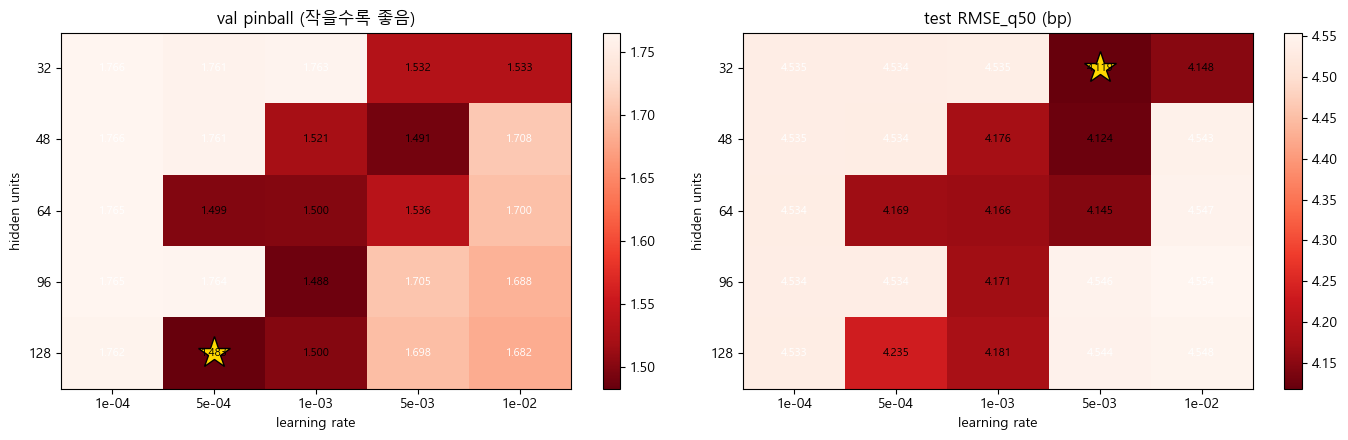

💾 reports/figures/w5_01_grid_heatmap.png


In [7]:
# Heatmap — val pinball
pivot_val = grid_df.pivot(index='hidden', columns='lr', values='best_val_pinball')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (mat, title, cmap) in zip(axes, [
        (pivot_val, 'val pinball (작을수록 좋음)', 'Reds_r'),
        (grid_df.pivot(index='hidden', columns='lr', values='test_rmse_q50_bp'),
         'test RMSE_q50 (bp)', 'Reds_r')]):
    im = ax.imshow(mat.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(LRS))); ax.set_xticklabels([f'{x:.0e}' for x in LRS])
    ax.set_yticks(range(len(HIDDENS))); ax.set_yticklabels(HIDDENS)
    ax.set_xlabel('learning rate'); ax.set_ylabel('hidden units')
    ax.set_title(title)
    for i in range(len(HIDDENS)):
        for j in range(len(LRS)):
            ax.text(j, i, f'{mat.values[i,j]:.3f}', ha='center', va='center',
                    fontsize=8, color='white' if mat.values[i,j] > mat.values.mean() else 'black')
    plt.colorbar(im, ax=ax)
    # best 위치 표시
    bi, bj = np.unravel_index(np.argmin(mat.values), mat.values.shape)
    ax.plot(bj, bi, marker='*', markersize=24, markerfacecolor='gold', markeredgecolor='black')
plt.tight_layout()
plt.savefig(FIG_DIR/'w5_01_grid_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'💾 reports/figures/w5_01_grid_heatmap.png')

---

## 3. A0 final baseline — best HP 로 multi-seed 재학습

In [8]:
print(f'A0 final: hidden={BEST_HIDDEN}, lr={BEST_LR}, seeds={SEEDS}')
final_rows = []
final_models = {}
for sd in SEEDS:
    m, best_val, hist, n_ep = train_one(
        Xs_train_a0, ys_train, Xs_val_a0, ys_val,
        hidden=BEST_HIDDEN, layers=LSTM_CFG['num_layers'],
        dropout=LSTM_CFG['dropout'], lr=BEST_LR,
        batch_size=LSTM_CFG['batch_size'], max_epochs=LSTM_CFG['epochs'],
        patience=LSTM_CFG['early_stopping_patience'], seed=sd)
    final_models[sd] = m
    for split_name, Xs, y in [('train', Xs_train_a0, ys_train),
                              ('val', Xs_val_a0, ys_val),
                              ('test', Xs_test_a0, ys_test)]:
        ev = evaluate(predict_sorted(m, Xs), y, split_name)
        ev['seed']=sd; ev['n_epochs']=n_ep; ev['best_val_pinball']=best_val
        final_rows.append(ev)
    print(f'  seed={sd}: best_val={best_val:.4f}, epochs={n_ep}')

final_df = pd.DataFrame(final_rows)
final_df.to_csv(REPORT_DIR/'lstm_a0_final_eval_w5.csv', index=False)

# Best seed 의 모델을 산출물로 저장
best_seed_idx = final_df[final_df['split']=='val'].sort_values('pinball_q50').iloc[0]
BEST_SEED = int(best_seed_idx['seed'])
print(f'\n🏆 Best seed (val pinball): {BEST_SEED}')
torch.save({
    'state_dict': final_models[BEST_SEED].state_dict(),
    'config': {'features':[f'd_{c}' for c in FROZEN], 'lookback':LOOKBACK,
               'hidden':BEST_HIDDEN, 'layers':LSTM_CFG['num_layers'],
               'dropout':LSTM_CFG['dropout'], 'lr':BEST_LR,
               'quantiles':QUANTILES, 'seed':BEST_SEED},
}, MODELS_DIR/'lstm_a0_final_w5.pt')
print(f'💾 models/lstm_a0_final_w5.pt')

test_final = final_df[final_df['split']=='test']
print(f'\n=== A0 final (test split) — mean ± std ===')
for m in metrics:
    mean, std = test_final[m].mean(), test_final[m].std()
    print(f'  {m:18s}  {mean:.4f} ± {std:.4f}')

A0 final: hidden=128, lr=0.0005, seeds=[42, 123, 2024]


  seed=42: best_val=1.4830, epochs=49


  seed=123: best_val=1.5001, epochs=52


  seed=2024: best_val=1.5057, epochs=50

🏆 Best seed (val pinball): 123
💾 models/lstm_a0_final_w5.pt

=== A0 final (test split) — mean ± std ===
  pinball_q50         1.5587 ± 0.0145
  coverage_90         0.9023 ± 0.0135
  sharpness_bp        12.8154 ± 0.7072
  rmse_q50_bp         4.1953 ± 0.0351
  dir_acc_q50         0.6375 ± 0.0126


---

## 4. A1' Ablation (필수) — A0 + Δkrw_usd[t-1]

**가설**: 환율 차분의 1일 lag 효과가 한국 채권 변화량 예측에 의미 있는 SHAP 기여.

In [9]:
# A0 8 Δfeatures + Δkrw_usd[t-1] = 9 Δfeatures
krw_usd_aligned = raw_wide['krw_usd'].reindex(fv.index)
fv_a1 = fv[FROZEN].copy()
fv_a1['krw_usd'] = krw_usd_aligned
FROZEN_A1 = FROZEN + ['krw_usd']
df_diff_a1 = build_diff_features(fv_a1, FROZEN_A1)
scaler_a1, X_train_a1, X_cal_a1, X_val_a1, X_test_a1 = fit_scaler_and_transform(df_diff_a1)
Xs_train_a1, ys_train_a1, _      = make_sequences(X_train_a1, y_train, LOOKBACK)
Xs_val_a1,   ys_val_a1,   dt_val_a1  = make_sequences(X_val_a1,   y_val,   LOOKBACK)
Xs_test_a1,  ys_test_a1,  dt_test_a1 = make_sequences(X_test_a1,  y_test,  LOOKBACK)
print(f"A1' 시퀀스: train{Xs_train_a1.shape} val{Xs_val_a1.shape} test{Xs_test_a1.shape}")

a1_rows = []
a1_models = {}
for sd in SEEDS:
    m, best_val, hist, n_ep = train_one(
        Xs_train_a1, ys_train_a1, Xs_val_a1, ys_val_a1,
        hidden=BEST_HIDDEN, layers=LSTM_CFG['num_layers'],
        dropout=LSTM_CFG['dropout'], lr=BEST_LR,
        batch_size=LSTM_CFG['batch_size'], max_epochs=LSTM_CFG['epochs'],
        patience=LSTM_CFG['early_stopping_patience'], seed=sd)
    a1_models[sd] = m
    for split_name, Xs, y in [('train',Xs_train_a1, ys_train_a1),
                              ('val',  Xs_val_a1,   ys_val_a1),
                              ('test', Xs_test_a1,  ys_test_a1)]:
        ev = evaluate(predict_sorted(m, Xs), y, split_name)
        ev['seed']=sd; ev['model']="A1'_Δkrw_usd"
        a1_rows.append(ev)
    print(f'  seed={sd}: best_val={best_val:.4f}, epochs={n_ep}')

a1_df = pd.DataFrame(a1_rows)
a1_df.to_csv(REPORT_DIR/'ablation_a1_w5.csv', index=False)
test_a1 = a1_df[a1_df['split']=='test']
print(f"\n=== A1' (test, mean ± std) ===")
for m in metrics:
    print(f'  {m:18s}  {test_a1[m].mean():.4f} ± {test_a1[m].std():.4f}')

A1' 시퀀스: train(2524, 30, 9) val(205, 30, 9) test(672, 30, 9)


  seed=42: best_val=1.4864, epochs=48


  seed=123: best_val=1.4784, epochs=51


  seed=2024: best_val=1.4935, epochs=55

=== A1' (test, mean ± std) ===
  pinball_q50         1.5614 ± 0.0130
  coverage_90         0.8938 ± 0.0060
  sharpness_bp        12.5401 ± 0.5494
  rmse_q50_bp         4.2037 ± 0.0260
  dir_acc_q50         0.6305 ± 0.0168


In [10]:
# A0 vs A1' 직접 비교 (test split mean)
print(f"=== A0 vs A1' (test mean ± std) — Δ(A1' - A0) ===")
delta_rows = []
for m in metrics:
    a0_mean, a0_std = test_final[m].mean(), test_final[m].std()
    a1_mean, a1_std = test_a1[m].mean(), test_a1[m].std()
    delta = a1_mean - a0_mean
    delta_rows.append({'metric':m, 'A0':round(a0_mean,4), 'A1\'':round(a1_mean,4),
                       'Δ':round(delta,4), 'A0_std':round(a0_std,4), 'A1\'_std':round(a1_std,4)})
    sign = '🟢' if (m=='dir_acc_q50' and delta>0) or (m!='dir_acc_q50' and m!='coverage_90' and delta<0) else ('🔴' if (m=='dir_acc_q50' and delta<0) else '⚪')
    print(f'  {m:18s}  A0 {a0_mean:.4f}  →  A1\' {a1_mean:.4f}  Δ={delta:+.4f}  {sign}')
delta_a1_df = pd.DataFrame(delta_rows)
print('\n💾 reports/ablation_a1_w5.csv')

=== A0 vs A1' (test mean ± std) — Δ(A1' - A0) ===
  pinball_q50         A0 1.5587  →  A1' 1.5614  Δ=+0.0027  ⚪
  coverage_90         A0 0.9023  →  A1' 0.8938  Δ=-0.0084  ⚪
  sharpness_bp        A0 12.8154  →  A1' 12.5401  Δ=-0.2753  🟢
  rmse_q50_bp         A0 4.1953  →  A1' 4.2037  Δ=+0.0085  ⚪
  dir_acc_q50         A0 0.6375  →  A1' 0.6305  Δ=-0.0070  🔴

💾 reports/ablation_a1_w5.csv


---

## 5. A2' Ablation (선택) — A0 + Δkospi[t-1]

**가설**: 국내 위험자산 채널 (W3 freeze 단계 Granger p=0.57 로 제외, 차분에서는 다른 결과 가능).

사전 점검: `corr(Δkospi[t-1], Δy_t)` 가 의미 있는 신호 보일 때만 실행.

In [11]:
kospi_aligned = raw_wide['kospi'].reindex(fv.index)
dy = (fv['kr_treasury_10y'].diff() * 100).dropna()
dkospi_lag1 = kospi_aligned.diff().shift(1)
common = dy.index.intersection(dkospi_lag1.dropna().index)
corr_dk = dkospi_lag1.loc[common].corr(dy.loc[common])
print(f'corr( Δkospi[t-1], Δy_t ) = {corr_dk:+.4f}')
RUN_A2 = abs(corr_dk) >= 0.05
print(f'A2\' 실행 여부: {"✅ 실행 (|r|≥0.05)" if RUN_A2 else "⏸ 건너뜀 (|r|<0.05, 음수 채택 원칙)"}')
a2_df = pd.DataFrame()  # 기본 빈 df

corr( Δkospi[t-1], Δy_t ) = -0.0097
A2' 실행 여부: ⏸ 건너뜀 (|r|<0.05, 음수 채택 원칙)


In [12]:
if RUN_A2:
    fv_a2 = fv[FROZEN].copy(); fv_a2['kospi'] = kospi_aligned
    df_diff_a2 = build_diff_features(fv_a2, FROZEN + ['kospi'])
    scaler_a2, X_train_a2, X_cal_a2, X_val_a2, X_test_a2 = fit_scaler_and_transform(df_diff_a2)
    Xs_train_a2, ys_train_a2, _      = make_sequences(X_train_a2, y_train, LOOKBACK)
    Xs_val_a2,   ys_val_a2,   _       = make_sequences(X_val_a2,   y_val,   LOOKBACK)
    Xs_test_a2,  ys_test_a2,  _       = make_sequences(X_test_a2,  y_test,  LOOKBACK)
    a2_rows = []
    for sd in SEEDS:
        m, best_val, hist, n_ep = train_one(
            Xs_train_a2, ys_train_a2, Xs_val_a2, ys_val_a2,
            hidden=BEST_HIDDEN, layers=LSTM_CFG['num_layers'],
            dropout=LSTM_CFG['dropout'], lr=BEST_LR,
            batch_size=LSTM_CFG['batch_size'], max_epochs=LSTM_CFG['epochs'],
            patience=LSTM_CFG['early_stopping_patience'], seed=sd)
        for split_name, Xs, y in [('train',Xs_train_a2,ys_train_a2),('val',Xs_val_a2,ys_val_a2),('test',Xs_test_a2,ys_test_a2)]:
            ev = evaluate(predict_sorted(m, Xs), y, split_name)
            ev['seed']=sd; ev['model']="A2'_Δkospi"
            a2_rows.append(ev)
        print(f'  seed={sd}: best_val={best_val:.4f}')
    a2_df = pd.DataFrame(a2_rows)
    a2_df.to_csv(REPORT_DIR/'ablation_a2_w5.csv', index=False)
    test_a2 = a2_df[a2_df['split']=='test']
    print(f"\n=== A2' (test mean ± std) ===")
    for m in metrics:
        print(f'  {m:18s}  {test_a2[m].mean():.4f} ± {test_a2[m].std():.4f}')
else:
    print('A2\' 건너뜀 — corr 사전 점검 미충족 (음수 채택 원칙 §3.2.c)')

A2' 건너뜀 — corr 사전 점검 미충족 (음수 채택 원칙 §3.2.c)


---

## 6. A3' Ablation (선택) — A0 + Δkr_ppi[t-1]

**가설**: SHAP 2위(W1 in-sample) 변수의 차분 형태 lag 효과.

**CL-01 발표일 시프트**: kr_ppi 는 익월 25일경 발표 → +1개월 lag 강제 후 차분.

In [13]:
# kr_ppi 발표일 시프트 + 차분
kr_ppi_announced = raw_wide['kr_ppi'].shift(freq='30D').reindex(fv.index, method='ffill')
dkr_ppi_lag1 = kr_ppi_announced.diff().shift(1)
common = dy.index.intersection(dkr_ppi_lag1.dropna().index)
corr_pp = dkr_ppi_lag1.loc[common].corr(dy.loc[common])
print(f'corr( Δkr_ppi_announced[t-1], Δy_t ) = {corr_pp:+.4f}')
RUN_A3 = abs(corr_pp) >= 0.05
print(f'A3\' 실행 여부: {"✅ 실행" if RUN_A3 else "⏸ 건너뜀"}')
a3_df = pd.DataFrame()

corr( Δkr_ppi_announced[t-1], Δy_t ) = -0.0019
A3' 실행 여부: ⏸ 건너뜀


In [14]:
if RUN_A3:
    fv_a3 = fv[FROZEN].copy(); fv_a3['kr_ppi'] = kr_ppi_announced
    df_diff_a3 = build_diff_features(fv_a3, FROZEN + ['kr_ppi'])
    scaler_a3, X_train_a3, X_cal_a3, X_val_a3, X_test_a3 = fit_scaler_and_transform(df_diff_a3)
    Xs_train_a3, ys_train_a3, _ = make_sequences(X_train_a3, y_train, LOOKBACK)
    Xs_val_a3,   ys_val_a3,   _ = make_sequences(X_val_a3,   y_val,   LOOKBACK)
    Xs_test_a3,  ys_test_a3,  _ = make_sequences(X_test_a3,  y_test,  LOOKBACK)
    a3_rows = []
    for sd in SEEDS:
        m, best_val, hist, n_ep = train_one(
            Xs_train_a3, ys_train_a3, Xs_val_a3, ys_val_a3,
            hidden=BEST_HIDDEN, layers=LSTM_CFG['num_layers'],
            dropout=LSTM_CFG['dropout'], lr=BEST_LR,
            batch_size=LSTM_CFG['batch_size'], max_epochs=LSTM_CFG['epochs'],
            patience=LSTM_CFG['early_stopping_patience'], seed=sd)
        for split_name, Xs, y in [('train',Xs_train_a3,ys_train_a3),('val',Xs_val_a3,ys_val_a3),('test',Xs_test_a3,ys_test_a3)]:
            ev = evaluate(predict_sorted(m, Xs), y, split_name)
            ev['seed']=sd; ev['model']="A3'_Δkr_ppi"
            a3_rows.append(ev)
        print(f'  seed={sd}: best_val={best_val:.4f}')
    a3_df = pd.DataFrame(a3_rows)
    a3_df.to_csv(REPORT_DIR/'ablation_a3_w5.csv', index=False)
    test_a3 = a3_df[a3_df['split']=='test']
    print(f"\n=== A3' (test mean ± std) ===")
    for m in metrics:
        print(f'  {m:18s}  {test_a3[m].mean():.4f} ± {test_a3[m].std():.4f}')
else:
    print('A3\' 건너뜀 — corr 사전 점검 미충족')

A3' 건너뜀 — corr 사전 점검 미충족


---

## 7. (선택) CQR 후처리 — Conformal Quantile Regression (계획서 §5.6)

- Calibration set: 2021 (cal split, exchangeability 가정 일부)
- 절차:
  1. cal 에서 conformity score $E_i = \max(\hat q_{0.05} - y_i, y_i - \hat q_{0.95})$
  2. $\alpha=0.1$ 의 $(1-\alpha)(1+1/n)$ quantile = $Q$
  3. test 에서 $[\hat q_{0.05} - Q, \hat q_{0.95} + Q]$ 로 보정
- Coverage 회복 + Sharpness trade-off 측정

In [15]:
# A0 final best_seed 모델로 CQR 적용
model_for_cqr = final_models[BEST_SEED]
preds_cal = predict_sorted(model_for_cqr, Xs_cal_a0)
preds_test_a0 = predict_sorted(model_for_cqr, Xs_test_a0)

# Conformity score on cal
E_cal = np.maximum(preds_cal[0.05] - ys_cal, ys_cal - preds_cal[0.95])
alpha = 0.1
n_cal = len(E_cal)
k = int(np.ceil((n_cal + 1) * (1 - alpha)))
Q = float(np.sort(E_cal)[min(k-1, n_cal-1)])
print(f'Calibration N={n_cal}, conformity Q ({1-alpha:.0%} quantile, finite-sample 보정) = {Q:.3f} bp')

# Apply to test
preds_test_cqr = {
    0.05: preds_test_a0[0.05] - Q,
    0.5:  preds_test_a0[0.5],
    0.95: preds_test_a0[0.95] + Q,
}
ev_pre = evaluate(preds_test_a0, ys_test, 'test_pre_CQR')
ev_post = evaluate(preds_test_cqr, ys_test, 'test_post_CQR')
cqr_df = pd.DataFrame([ev_pre, ev_post])
cqr_df['Q_bp'] = Q
cqr_df.to_csv(REPORT_DIR/'cqr_post_w5.csv', index=False)
print(f'\n=== CQR 전후 (test split, A0 best_seed={BEST_SEED}) ===')
print(cqr_df[['split','pinball_q05','pinball_q50','pinball_q95','coverage_90','sharpness_bp','rmse_q50_bp']].to_string(index=False))
print(f'\n💾 reports/cqr_post_w5.csv')
print(f'\n📌 marginal coverage 보장은 점근적·근사 (계획서 §5.6 면책) — distribution shift 에서 깨질 수 있음')

Calibration N=209, conformity Q (90% quantile, finite-sample 보정) = 0.788 bp

=== CQR 전후 (test split, A0 best_seed=123) ===
        split  pinball_q05  pinball_q50  pinball_q95  coverage_90  sharpness_bp  rmse_q50_bp
 test_pre_CQR     0.432046     1.546618     0.437325     0.900298     12.343856     4.169856
test_post_CQR     0.439089     1.546618     0.441970     0.930060     13.919994     4.169856

💾 reports/cqr_post_w5.csv

📌 marginal coverage 보장은 점근적·근사 (계획서 §5.6 면책) — distribution shift 에서 깨질 수 있음


---

## 8. 통합 비교표 — Naive/ARIMA/XGBoost/W4 raw/A0/A1' (+A2'/A3' 시간 여유 시)

In [16]:
# Read W4 baseline + add W5 results
bw4 = pd.read_csv(REPORT_DIR/'baseline_results_w4.csv')
rows = bw4[bw4['split'].isin(['val','test'])].to_dict('records')

# A0 final
for sp in ['val','test']:
    sub = final_df[final_df['split']==sp]
    rows.append({'model':'A0_Δfeat[t-1]', 'split':sp,
                 'RMSE_bp':round(sub['rmse_q50_bp'].mean(),3),
                 'MAE_bp':round(sub['mae_q50_bp'].mean(),3),
                 'Dir_Acc':round(sub['dir_acc_q50'].mean(),3)})
# A1'
for sp in ['val','test']:
    sub = a1_df[a1_df['split']==sp]
    rows.append({'model':"A1'_+Δkrw_usd", 'split':sp,
                 'RMSE_bp':round(sub['rmse_q50_bp'].mean(),3),
                 'MAE_bp':round(sub['mae_q50_bp'].mean(),3),
                 'Dir_Acc':round(sub['dir_acc_q50'].mean(),3)})
# A2' (if run)
if RUN_A2 and not a2_df.empty:
    for sp in ['val','test']:
        sub = a2_df[a2_df['split']==sp]
        rows.append({'model':"A2'_+Δkospi", 'split':sp,
                     'RMSE_bp':round(sub['rmse_q50_bp'].mean(),3),
                     'MAE_bp':round(sub['mae_q50_bp'].mean(),3),
                     'Dir_Acc':round(sub['dir_acc_q50'].mean(),3)})
if RUN_A3 and not a3_df.empty:
    for sp in ['val','test']:
        sub = a3_df[a3_df['split']==sp]
        rows.append({'model':"A3'_+Δkr_ppi", 'split':sp,
                     'RMSE_bp':round(sub['rmse_q50_bp'].mean(),3),
                     'MAE_bp':round(sub['mae_q50_bp'].mean(),3),
                     'Dir_Acc':round(sub['dir_acc_q50'].mean(),3)})

bw5 = pd.DataFrame(rows)
bw5.to_csv(REPORT_DIR/'baseline_results_w5.csv', index=False)
print('=== W5 통합 비교표 ===')
print(bw5.to_string(index=False))
print(f'\n💾 reports/baseline_results_w5.csv')

=== W5 통합 비교표 ===


         model split  RMSE_bp  MAE_bp  Dir_Acc
  Naive (Δŷ=0)   val    7.101   5.483      NaN
  Naive (Δŷ=0)  test    4.647   3.477      NaN
ARIMA(1, 0, 1)   val    7.114   5.500    0.431
ARIMA(1, 0, 1)  test    4.651   3.483    0.497
  XGBoost(q50)   val    7.075   5.455    0.509
  XGBoost(q50)  test    4.644   3.469    0.512
     LSTM(q50)   val    7.390   5.761    0.456
     LSTM(q50)  test    4.535   3.391    0.495
 A0_Δfeat[t-1]   val    7.149   5.514    0.593
 A0_Δfeat[t-1]  test    4.195   3.117    0.638
 A1'_+Δkrw_usd   val    7.131   5.489    0.637
 A1'_+Δkrw_usd  test    4.204   3.123    0.630

💾 reports/baseline_results_w5.csv


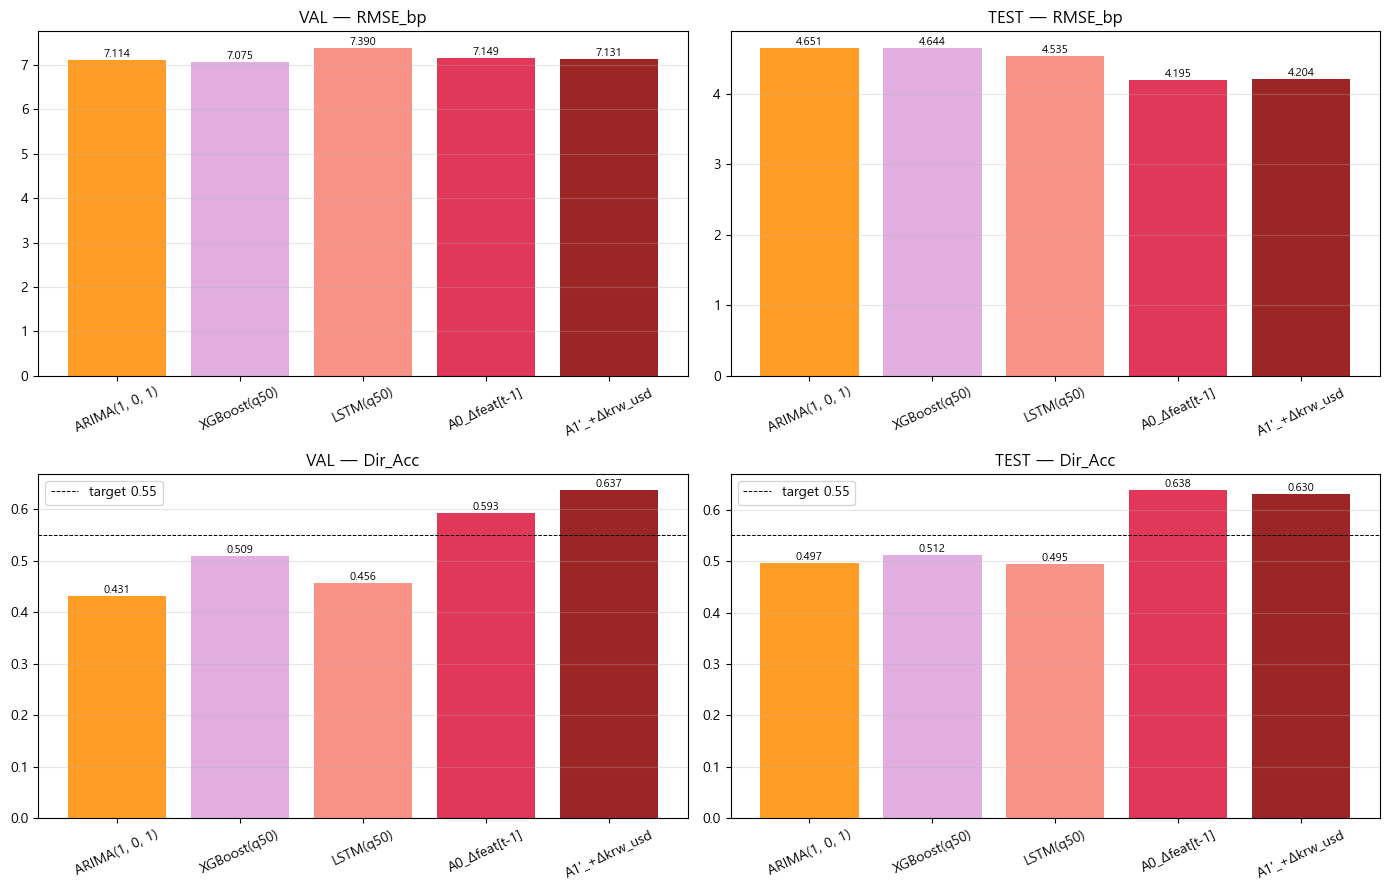

💾 reports/figures/w5_02_w5_compare.png


In [17]:
# 시각화 — val/test RMSE & Dir_Acc
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
model_order = ['Naive (Δŷ=0)','ARIMA(1, 0, 1)','XGBoost(q50)','LSTM(q50)','A0_Δfeat[t-1]',"A1'_+Δkrw_usd"]
if RUN_A2: model_order.append("A2'_+Δkospi")
if RUN_A3: model_order.append("A3'_+Δkr_ppi")
colors = {'Naive (Δŷ=0)':'steelblue','ARIMA(1, 0, 1)':'darkorange','XGBoost(q50)':'plum',
          'LSTM(q50)':'salmon','A0_Δfeat[t-1]':'crimson',
          "A1'_+Δkrw_usd":'darkred',"A2'_+Δkospi":'gray',"A3'_+Δkr_ppi":'gray'}

for ax, sp, metric in zip(axes.flat,
                           ['val','test','val','test'],
                           ['RMSE_bp','RMSE_bp','Dir_Acc','Dir_Acc']):
    sub = bw5[(bw5['split']==sp)].copy()
    sub = sub[sub['model'].isin(model_order) & sub[metric].notna()]
    sub = sub.set_index('model').reindex(model_order).dropna()
    bar_colors = [colors.get(m,'gray') for m in sub.index]
    ax.bar(sub.index, sub[metric], color=bar_colors, alpha=0.85)
    ax.set_title(f'{sp.upper()} — {metric}')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(alpha=0.3, axis='y')
    if metric == 'Dir_Acc':
        ax.axhline(0.55, color='black', linestyle='--', linewidth=0.7, label='target 0.55')
        ax.legend()
    for i, v in enumerate(sub[metric]):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/'w5_02_w5_compare.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'💾 reports/figures/w5_02_w5_compare.png')

---

## 9. 요약 + 다음 단계 (6주차)

### 본 노트북 산출물 → 6주차 입력

- `models/lstm_a0_final_w5.pt` — A0 best HP / best seed (**6주차 SHAP 재산출 대상**)
- `reports/lstm_a0_multiseed_w5.csv` — multi-seed robustness
- `reports/grid_5x5_w5.csv` — 25 조합 탐색 결과 + heatmap
- `reports/lstm_a0_final_eval_w5.csv` — A0 final (3 seed × 3 split)
- `reports/ablation_a1_w5.csv` — A1' Δkrw_usd 결과
- `reports/ablation_a2_w5.csv`, `reports/ablation_a3_w5.csv` — 시간 여유 시
- `reports/cqr_post_w5.csv` — CQR 전후 비교
- `reports/baseline_results_w5.csv` — Naive/ARIMA/XGB/W4 raw/A0/A1' 통합
- `reports/figures/w5_01_grid_heatmap.png`, `w5_02_w5_compare.png`

### TODO (5주차 마감)

- [ ] §1 multi-seed robustness → `VALIDATION_LOG.md` 기록 (1건)
- [ ] §4 A1' 환율 ablation 결과 → `VALIDATION_LOG.md` 기록 (1건, 음수 채택 원칙 적용)

### 6주차 작업 (`06_shap_error_analysis.ipynb`)

1. 분위수별 SHAP 분석 — q05/q50/q95 모델 각각 (계획서 §6.1)
2. 시차 효과 정량화 — SHAP heatmap 의 시간 lag 축 분석 (§6.3)
3. **오류 분석 4축** (§6.4): 방향성 오답 / 큰 변동 미예측 / Coverage Miss / 위기 vs 정상 SHAP 차이
4. 위기구간 정량 라벨 (§4.4) + 케이스 스터디
5. **DM test (HAC + HLN + Bonferroni)** — A0 vs Naive/XGBoost/LSTM raw 통계적 유의성 (§7)
6. 거시경제 채널 부합 검증 (§3.1 사전 가설 vs SHAP 결과)